In [4]:
import sleap
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from python.animation import *

sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


In [2]:
c3_labels_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/predictions/predictions/c3_predictions.slp.250120_125305.predictions.slp'
c3_labels = sleap.load_file(c3_labels_path)
c3_all_tracked_points = get_all_tracked_points(c3_labels, reorder=True)

all_tracked_points shape: (827, 17, 2)
Missing point count: 105


In [3]:
c3_all_tracked_points.shape

(827, 16, 2)

1. Find swapped IDs: when expanded (radius max), a point should be connected to its 2 closest neighbors; if not, considered as swapped
- ID the center 
- compute the radius for each point 
- if all point radius at least 50% max, ID as expanded

2. Correct (swap)

3. Propagate in time in both directions

## Identify frames where the jellyfish is expanded

### get center position

In [13]:
c3_labels.video.get_frame(1).shape

(170, 174, 1)

In [6]:
frame1 = c3_labels.video.get_frame(1)

In [12]:
center_x, center_y = 91, 77

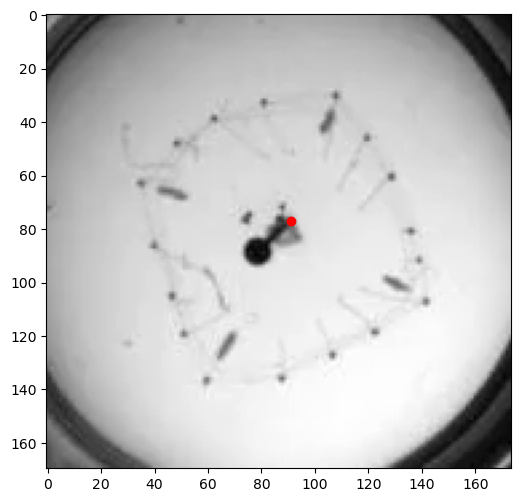

In [15]:
plt.figure(figsize=(6, 6))
plt.imshow(frame1[:,:,0], cmap='gray')
plt.plot(center_x, center_y, 'ro')
plt.show()